In [5]:
import yfinance as yf

df = yf.download("RELIANCE.NS", start="2015-01-01", end="2024-01-01")

ModuleNotFoundError: No module named 'yfinance'

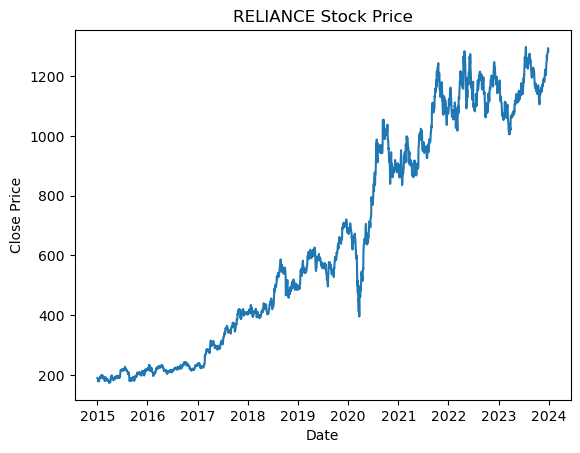

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df.index, df['Close'])
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("RELIANCE Stock Price")
plt.show()

In [ ]:
close_prices = df['Close'].values.reshape(-1,1)

scaler = MinMaxScaler(feature_range=(0,1))
scaled_close = scaler.fit_transform(close_prices)

In [ ]:
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step)])
        y.append(data[i+time_step])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_close, time_step)

# reshape for LSTM/GRU
X = X.reshape(X.shape[0], X.shape[1], 1)

In [ ]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model_lstm = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_step,1)),
    LSTM(50),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_train, y_train, epochs=5, batch_size=32)

Epoch 1/5


C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0206
Epoch 2/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 7.3581e-04
Epoch 3/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 7.2035e-04
Epoch 4/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 6.9508e-04
Epoch 5/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 6.9172e-04


In [ ]:
from tensorflow.keras.layers import GRU

model_gru = Sequential([
    GRU(50, return_sequences=True, input_shape=(time_step,1)),
    GRU(50),
    Dense(1)
])

model_gru.compile(optimizer='adam', loss='mse')
model_gru.fit(X_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0287
Epoch 2/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 3.2105e-04
Epoch 3/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 2.4971e-04
Epoch 4/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 2.3753e-04
Epoch 5/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 2.2129e-04


In [ ]:
pred_lstm = model_lstm.predict(X_test)
pred_gru  = model_gru.predict(X_test)

# reshape before inverse scaling
pred_lstm = pred_lstm.reshape(-1,1)
pred_gru  = pred_gru.reshape(-1,1)
y_test    = y_test.reshape(-1,1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step 
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step 


In [ ]:
pred_lstm = scaler.inverse_transform(pred_lstm)
pred_gru  = scaler.inverse_transform(pred_gru)
y_test_actual = scaler.inverse_transform(y_test)

In [ ]:
test_dates = df.index[len(df) - len(y_test_actual):]

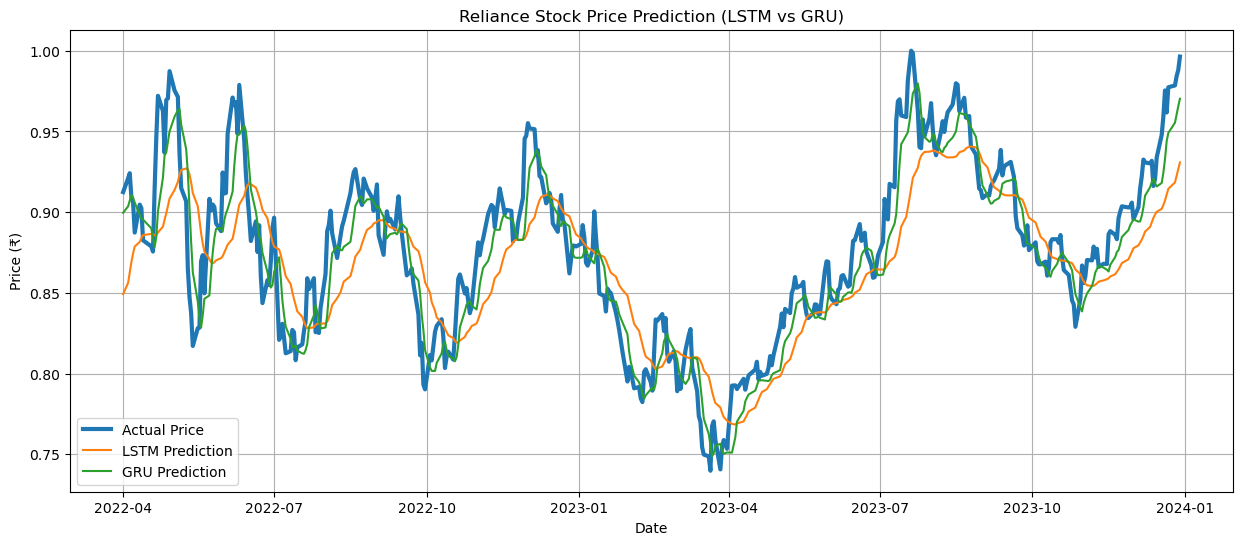

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(test_dates, y_test_actual, label="Actual Price", linewidth=3)
plt.plot(test_dates, pred_lstm, label="LSTM Prediction")
plt.plot(test_dates, pred_gru, label="GRU Prediction")

plt.title("Reliance Stock Price Prediction (LSTM vs GRU)")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid()
plt.show()